In [ ]:
%%capture
!pip install fairlearn

In [ ]:
#@markdown Load modules
import numpy as np
from IPython.display import display, Markdown, Latex
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.preprocessing import CorrelationRemover
from fairlearn.adversarial import AdversarialFairnessClassifier
from fairlearn.metrics import MetricFrame
import fairlearn.datasets as fdata
from fairlearn.metrics import (demographic_parity_difference, demographic_parity_ratio,
                               selection_rate_difference, false_negative_rate_difference,
                               false_positive_rate_difference, equalized_odds_ratio,
                               false_negative_rate, false_positive_rate)

# Load and preprocess the data

In [ ]:
#@markdown Load and read about the dataset.
# get datast from fairlearn and show description
dataset = fdata.fetch_diabetes_hospital()

display(Markdown(dataset.DESCR))

# save dataframe and features
x_raw = dataset.data
# y_raw = np.array(dataset.target)
feature_names = dataset.feature_names

The "Diabetes 130-Hospitals" dataset represents 10 years of clinical care at 130 U.S. hospitals and delivery networks, collected from 1999 to 2008. Each record represents the hospital admission record for a patient diagnosed with diabetes whose stay lasted between one to fourteen days. The features describing each encounter include demographics, diagnoses, diabetic medications, number of visits in the year preceding the encounter, and payer information, as well as whether the patient was readmitted after release, and whether the readmission occurred within 30 days of the release.

The original "Diabetes 130-Hospitals" dataset was collected by Beata Strack, Jonathan P. DeShazo, Chris Gennings, Juan L. Olmo, Sebastian Ventura, Krzysztof J. Cios, and John N. Clore in 2014.

This version of the dataset was derived by the Fairlearn team for the SciPy 2021 tutorial "Fairness in AI Systems: From social context to practice using Fairlearn". In this version, the target variable "readmitted" is binarized into whether the patient was re-admitted within thirty days. The full dataset pre-processing script can be found on GitHub: https://github.com/fairlearn/talks/blob/main/2021_scipy_tutorial/preprocess.py

Downloaded from openml.org.

You can read more about the dataset [here](https://fairlearn.org/main/user_guide/datasets/diabetes_hospital_data.html). In this description, we see that two features, `readmitted` and `readmit_binary`, are other representations of the same outcome, so we drop them from the set of predictors.

In [ ]:
#@markdown Down sample to make runtimes reasonable
x_raw = x_raw.sample(frac=0.1, random_state=123)

In [ ]:
y_raw = x_raw['readmit_binary']
x_raw = x_raw.drop(columns=['readmitted', 'readmit_binary'])
feature_names = feature_names[:-2]

In [ ]:
#@markdown Look at the first few rows of the data.
x_raw.head()

,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,max_glu_serum,A1Cresult,insulin,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days
65884,Caucasian,Male,'Over 60 years','Discharged to Home',Emergency,3,Missing,49,6,27,...,None,None,Up,Ch,Yes,False,False,False,True,False
86278,Caucasian,Female,'Over 60 years',Other,Referral,5,Missing,57,0,21,...,None,None,No,Ch,Yes,True,False,False,True,False
30000,Caucasian,Male,'30-60 years','Discharged to Home',Other,4,Other,37,2,9,...,None,None,No,No,No,False,False,False,False,False
51185,Caucasian,Male,'30-60 years',Other,Other,9,InternalMedicine,61,6,27,...,None,>8,No,Ch,Yes,False,False,True,False,True
53902,Caucasian,Female,'30-60 years','Discharged to Home',Referral,7,Other,23,0,13,...,None,None,No,No,Yes,True,False,True,True,False


## data inspectation

In [ ]:
#@markdown drop the rows with 'Unknown/Invalid' values for gender

# drop these 3 rows
print(x_raw.shape)
rows_to_keep = x_raw.gender != 'Unknown/Invalid'
x_raw = x_raw[rows_to_keep]
y_raw = y_raw[rows_to_keep]
print(x_raw.shape)

(10177, 22)
(10177, 22)


In [ ]:
#@markdown
unique_feature_values = x_raw.apply(np.unique, axis=0)
unique_feature_values

,0
race,"[AfricanAmerican, Asian, Caucasian, Hispanic, ..."
gender,"[Female, Male]"
age,"['30 years or younger', '30-60 years', 'Over 6..."
discharge_disposition_id,"['Discharged to Home', Other]"
admission_source_id,"[Emergency, Other, Referral]"
time_in_hospital,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]"
medical_specialty,"[Cardiology, Emergency/Trauma, Family/GeneralP..."
num_lab_procedures,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
num_procedures,"[0, 1, 2, 3, 4, 5, 6]"
num_medications,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."


In [ ]:
PALETTE = sns.color_palette("Set2", 6)

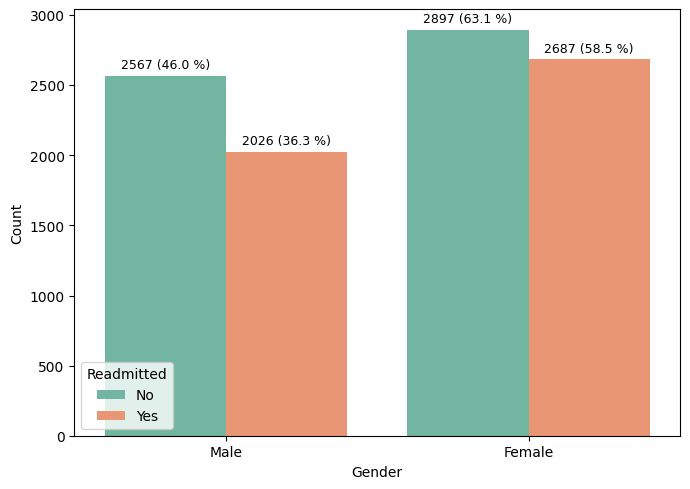

In [ ]:
df_plot = pd.DataFrame({'gender_Female': x_raw['gender'], 'readmitted': y_raw})
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df_plot, x='gender_Female', hue='readmitted', palette=[PALETTE[0], PALETTE[1]], ax=ax)
ax.set_title('', fontsize=13)
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Male', 'Female'])
ax.legend(title='Readmitted', labels=['No', 'Yes'])
plt.tight_layout()

# Calculate counts and percentages for labels
counts_data = df_plot.groupby(['gender_Female', 'readmitted']).size().unstack(fill_value=0)
total_gender_counts = counts_data.sum(axis=1)
for i, container in enumerate(ax.containers):
    readmitted_val_for_container = 0 if i == 0 else 1

    for j, p in enumerate(container.patches):
        height = p.get_height()
        if height > 0:
            # The x-category (gender_Female value) for this patch
            # Get the actual category label from the counts_data index
            gender_category_label = counts_data.index[j]

            total_for_this_gender = total_gender_counts.loc[gender_category_label]
            percentage = (height / total_for_this_gender) * 100

            ax.annotate(f'{int(height)} ({percentage:.1f} %)', # Format as 'count (percentage)'
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3),
                        textcoords='offset points')

plt.show()

In [ ]:
gender_proportions = df_plot.groupby('gender_Female')['readmitted'].value_counts(normalize=True).unstack()
print("Proportion of Gender by Readmission Status:")
print(gender_proportions)

Proportion of Gender by Readmission Status:
readmitted            0         1
gender_Female                    
Female         0.518804  0.481196
Male           0.558894  0.441106


In [ ]:
#@markdown
binary_features = unique_feature_values.index[[len(x) == 2 for x in unique_feature_values]].values
print(f'Binary features: {binary_features}')
categorical_features = unique_feature_values.index[[len(x) > 2 and isinstance(x[0], str) for x in unique_feature_values]].values
print(f'Categorical features: {categorical_features}')

Binary features: ['gender' 'discharge_disposition_id' 'change' 'diabetesMed' 'medicare'
 'medicaid' 'had_emergency' 'had_inpatient_days' 'had_outpatient_days']
Categorical features: ['race' 'age' 'admission_source_id' 'medical_specialty'
 'primary_diagnosis' 'max_glu_serum' 'A1Cresult' 'insulin']


In [ ]:
#@markdown standardize data types
for col_name in feature_names:
    if col_name in categorical_features:
        x_raw[col_name] = x_raw[col_name].astype('category')
    elif col_name in binary_features:  # redundant for clarity
        # turn into int column
        integer_col = (x_raw[col_name] == unique_feature_values[col_name][0]).astype(int)
        new_name = f'{col_name}_{unique_feature_values[col_name][0]}'
        x_raw[new_name] = integer_col
        x_raw.drop(columns=[col_name], inplace=True)

In [ ]:
#@markdown
%%capture
x_raw.apply(np.unique, axis=0)

In [ ]:
x_raw.dtypes

,0
race,category
age,category
admission_source_id,category
time_in_hospital,int64
medical_specialty,category
num_lab_procedures,int64
num_procedures,int64
num_medications,int64
primary_diagnosis,category
number_diagnoses,int64


In [ ]:
#@markdown One-hot encode categorical features
x_numeric = pd.get_dummies(x_raw)
display(x_numeric.head())

# get one-hot and numeric column names
numeric_cols = x_numeric.dtypes.index[x_numeric.dtypes == 'int64'].values
one_hot_cols = x_numeric.dtypes.index[x_numeric.dtypes != 'int64'].values

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,gender_Female,discharge_disposition_id_'Discharged to Home',change_Ch,diabetesMed_No,medicare_False,...,max_glu_serum_None,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_None,A1Cresult_Norm,insulin_Down,insulin_No,insulin_Steady,insulin_Up
65884,3,49,6,27,9,0,1,1,0,1,...,True,False,False,False,True,False,False,False,False,True
86278,5,57,0,21,9,1,0,1,0,0,...,True,False,False,False,True,False,False,True,False,False
30000,4,37,2,9,5,0,1,0,1,1,...,True,False,False,False,True,False,False,True,False,False
51185,9,61,6,27,9,0,0,1,0,1,...,True,False,False,True,False,False,False,True,False,False
53902,7,23,0,13,7,1,1,0,0,0,...,True,False,False,False,True,False,False,True,False,False


 # TODO: Split train, test data 80 train / 20 test


In [ ]:
# write your code here

X_train, X_test, y_train, y_test = train_test_split(x_numeric, y_raw, test_size=0.2, random_state=42 )

# Problem 2, Part (a)
### **Train a baseline Random Forest (RF) (sklearn RandomForestClassifier) model and report metrics**

### Train a random forest model - Baseline

In [ ]:
# write your code here
# initialize a model with RandomForestClassifier
n_estimators = 1

# train the model with the training data split
rfc_model = RandomForestClassifier(n_estimators=1, random_state=42)
rfc_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1, random_state=42)

### Report metrics

Calculate metrics with Fairlearn MetricFrame


In [ ]:
# write your code here

# get model's prediction for the test set
y_pred_baseline = rfc_model.predict(X_test)

# use MetricFrame to get the results

metric_dict = {
    'Accuracy': accuracy_score,
    'Precision': precision_score,
    'Recall': recall_score,
    'FNR': false_negative_rate,
    'FPR': false_positive_rate}
sample_params = {}

metric_frame_baseline = MetricFrame(
    metrics=metric_dict,
    y_true=y_test,
    y_pred=y_pred_baseline,
    sensitive_features=X_test['gender_Female'],
    sample_params=sample_params
)


Print Results

In [ ]:
# Overall metrics
print("=== Overall metrics ===")
print(metric_frame_baseline.overall)

# Group-specific metrics
print("\n=== Metrics by gender ===")
print(metric_frame_baseline.by_group)

=== Overall metrics ===
Accuracy     0.546169
Precision    0.503582
Recall       0.528464
FNR          0.471536
FPR          0.438914
dtype: float64

=== Metrics by gender ===
               Accuracy  Precision    Recall       FNR       FPR
gender_Female                                                   
0              0.550379   0.495238  0.506083  0.493917  0.414062
1              0.542677   0.509874  0.546154  0.453846  0.460371


In [ ]:
fnr_diff_baseline = false_negative_rate_difference(y_test, y_pred_baseline, sensitive_features=X_test['gender_Female'])
fpr_diff_baseline = false_positive_rate_difference(y_test, y_pred_baseline, sensitive_features=X_test['gender_Female'])
dp_ratio_baseline = demographic_parity_ratio(y_test, y_pred_baseline, sensitive_features=X_test['gender_Female'])
eo_ratio_baseline = equalized_odds_ratio(y_test, y_pred_baseline, sensitive_features=X_test['gender_Female'])
sel_diff_baseline = selection_rate_difference(y_test, y_pred_baseline, sensitive_features=X_test['gender_Female'])

print("\n=== Fairness Metrics ===")
print(f"FNR Difference: {fnr_diff_baseline:.4f}")
print(f"FPR Difference: {fpr_diff_baseline:.4f}")
print(f"Demographic Parity Ratio: {dp_ratio_baseline:.4f}")
print(f"Equalized Odds Ratio: {eo_ratio_baseline:.4f}")
print(f"Selection Rate Difference: {sel_diff_baseline:.4f}")

metrics_baseline = {
    'overall': metric_frame_baseline.overall.to_dict(),
    'FNR_diff': fnr_diff_baseline,
    'FPR_diff': fpr_diff_baseline,
    'DP_ratio': dp_ratio_baseline,
    'EO_ratio': eo_ratio_baseline,
    'Sel_diff': sel_diff_baseline,
}


=== Fairness Metrics ===
FNR Difference: 0.0401
FPR Difference: 0.0463
Demographic Parity Ratio: 0.9093
Equalized Odds Ratio: 0.8994
Selection Rate Difference: 0.0454


# Problem 2, Part (b)

Train another classifier with the following value of hyperparameters

In [ ]:
# write your code here
n_estimators = 1000
max_depth = 10
rfc_model_optimized = RandomForestClassifier(n_estimators=1000, max_depth = 10, random_state=42)
rfc_model_optimized.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=1000, random_state=42)

In [ ]:
# get model's prediction for the test set
y_pred_optimized = rfc_model_optimized.predict(X_test)

# use MetricFrame to get the results

metric_dict = {
    'Accuracy': accuracy_score,
    'Precision': precision_score,
    'Recall': recall_score,
    'FNR': false_negative_rate,
    'FPR': false_positive_rate}
sample_params = {}

metric_frame = MetricFrame(
    metrics=metric_dict,
    y_true=y_test,
    y_pred=y_pred_optimized,
    sensitive_features=X_test['gender_Female'],
    sample_params=sample_params
)


In [ ]:
# Overall metrics
print("=== Overall metrics ===")
print(metric_frame.overall)

# Group-specific metrics
print("\n=== Metrics by gender ===")
print(metric_frame.by_group)

=== Overall metrics ===
Accuracy     0.600196
Precision    0.583452
Recall       0.439313
FNR          0.560687
FPR          0.264253
dtype: float64

=== Metrics by gender ===
               Accuracy  Precision    Recall       FNR      FPR
gender_Female                                                  
0              0.596966   0.566102  0.406326  0.593674  0.25000
1              0.602875   0.596059  0.465385  0.534615  0.27656


Calculate metrics with Fairlearn MetricFrame
and print the results

In [ ]:
fnr_diff = false_negative_rate_difference(y_test, y_pred_optimized, sensitive_features=X_test['gender_Female'])
fpr_diff = false_positive_rate_difference(y_test, y_pred_optimized, sensitive_features=X_test['gender_Female'])
dp_ratio = demographic_parity_ratio(y_test, y_pred_optimized, sensitive_features=X_test['gender_Female'])
eo_ratio = equalized_odds_ratio(y_test, y_pred_optimized, sensitive_features=X_test['gender_Female'])
sel_diff = selection_rate_difference(y_test, y_pred_optimized, sensitive_features=X_test['gender_Female'])

print("\n=== Fairness Metrics ===")
print(f"FNR Difference: {fnr_diff:.4f}")
print(f"FPR Difference: {fpr_diff:.4f}")
print(f"Demographic Parity Ratio: {dp_ratio:.4f}")
print(f"Equalized Odds Ratio: {eo_ratio:.4f}")
print(f"Selection Rate Difference: {sel_diff:.4f}")


=== Fairness Metrics ===
FNR Difference: 0.0591
FPR Difference: 0.0266
Demographic Parity Ratio: 0.8762
Equalized Odds Ratio: 0.8731
Selection Rate Difference: 0.0452


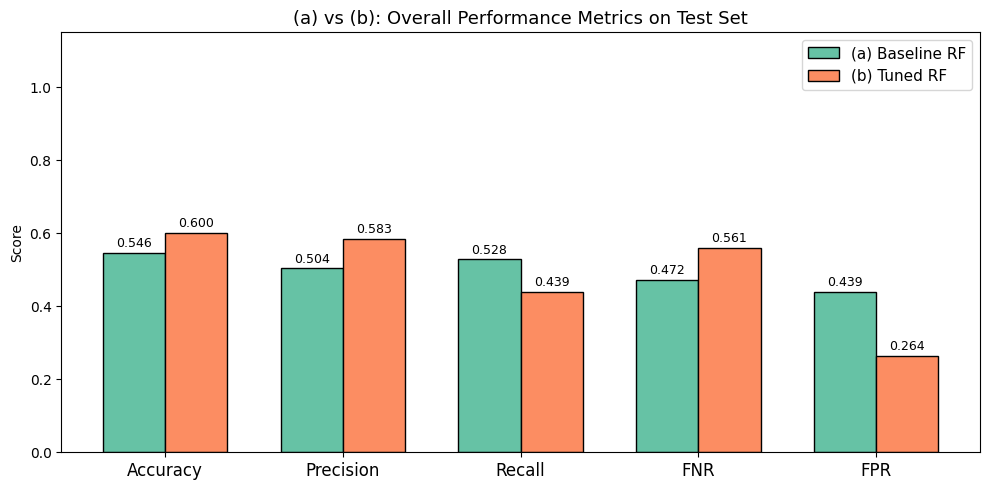

In [ ]:
overall_metrics_names = list(metric_dict.keys())
vals_a_ov = [metric_frame_baseline.overall[k] for k in overall_metrics_names]
vals_b_ov = [metric_frame.overall[k] for k in overall_metrics_names]

x_pos = np.arange(len(overall_metrics_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x_pos - width/2, vals_a_ov, width, label='(a) Baseline RF', color=PALETTE[0], edgecolor='black')
b2 = ax.bar(x_pos + width/2, vals_b_ov, width, label='(b) Tuned RF', color=PALETTE[1], edgecolor='black')
ax.set_xticks(x_pos); ax.set_xticklabels(overall_metrics_names, fontsize=12)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.15)
ax.set_title('(a) vs (b): Overall Performance Metrics on Test Set', fontsize=13)
ax.legend(fontsize=11)
ax.bar_label(b1, fmt='%.3f', fontsize=9, padding=2)
ax.bar_label(b2, fmt='%.3f', fontsize=9, padding=2)
plt.tight_layout()
plt.show()

**Let's compapre metrics following gender**

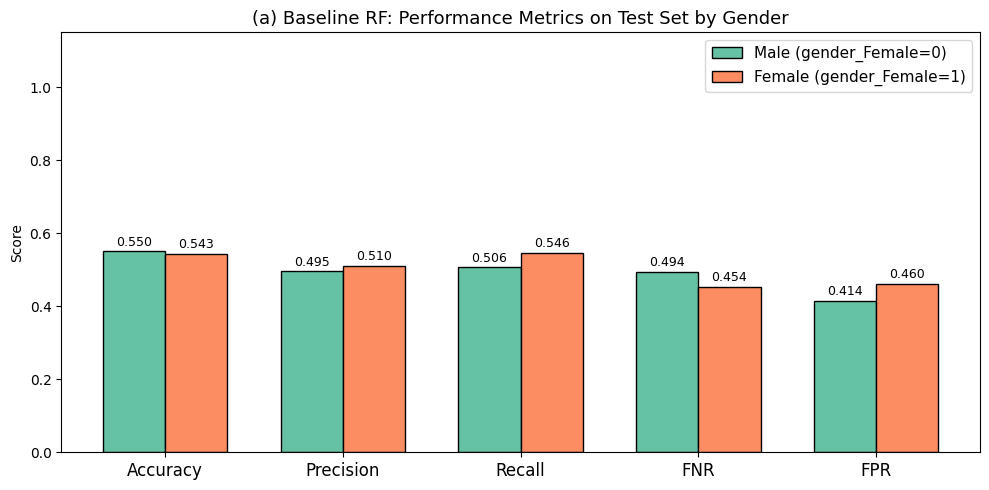

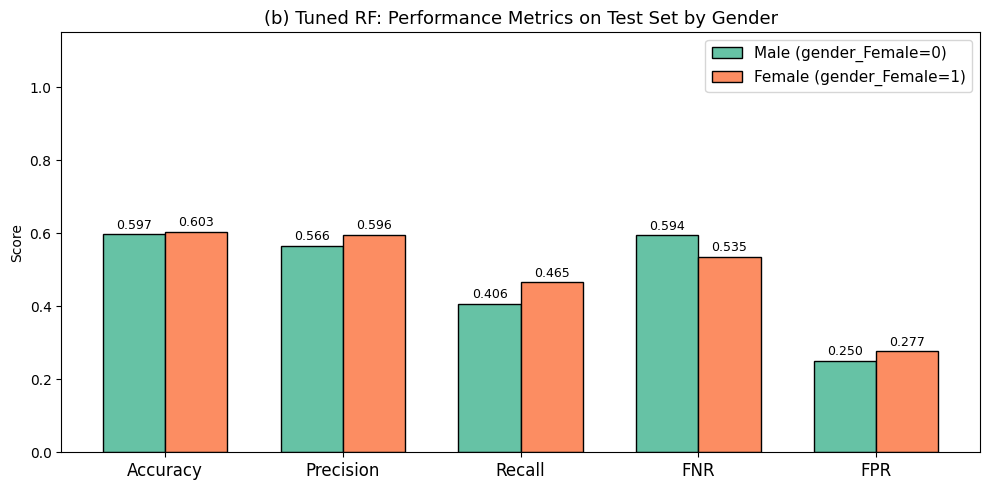

In [ ]:
model_data = {
    '(a) Baseline RF': metric_frame_baseline.by_group,
    '(b) Tuned RF': metric_frame.by_group
}

# Removed model_colors dictionary as colors will be consistent for gender across models

for model_name, metrics_df in model_data.items():
    fig, ax = plt.subplots(figsize=(10, 5))

    # Extract metrics for Male (gender_Female = 0) and Female (gender_Female = 1)
    vals_male = [metrics_df.loc[0][k] for k in overall_metrics_names]
    vals_female = [metrics_df.loc[1][k] for k in overall_metrics_names]

    x_pos = np.arange(len(overall_metrics_names))
    width = 0.35

    # Assign consistent colors for male and female across both models
    b1 = ax.bar(x_pos - width/2, vals_male, width, label='Male (gender_Female=0)', color=PALETTE[0], edgecolor='black')
    b2 = ax.bar(x_pos + width/2, vals_female, width, label='Female (gender_Female=1)', color=PALETTE[1], edgecolor='black')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(overall_metrics_names, fontsize=12)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.15)
    ax.set_title(f'{model_name}: Performance Metrics on Test Set by Gender', fontsize=13)
    ax.legend(fontsize=11)
    ax.bar_label(b1, fmt='%.3f', fontsize=9, padding=2)
    ax.bar_label(b2, fmt='%.3f', fontsize=9, padding=2)
    plt.tight_layout()
    plt.show()

# Problem 2, Part (c)
### **Fit Fairlean Adversarial Debiaser**

Experiment with the alpha parameter - which value of alpha produces the fairest and most accurate classifier? Does such a value exist?

In [ ]:
FAIRNESS_FUNCS = {
    'FNR_diff': false_negative_rate_difference,
    'FPR_diff': false_positive_rate_difference,
    'DP_ratio': demographic_parity_ratio,
    'EO_ratio': equalized_odds_ratio,
    'Sel_diff': selection_rate_difference,
}
sensitive_test  = X_test['gender_Female']
sensitive_train = X_train['gender_Female']

In [ ]:
def compute_all_metrics(y_true, y_pred, sensitive):
    mf = MetricFrame(
        metrics=metric_dict,
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive,
    )
    result = {}
    result['overall']  = mf.overall.to_dict()
    result['by_group'] = mf.by_group.to_dict()
    for name, fn in FAIRNESS_FUNCS.items():
        result[name] = fn(y_true, y_pred, sensitive_features=sensitive)
    return result

In [ ]:
#@markdown Fit the AdversarialFairnessClassifier here.
#@markdown Use these hyperparameters, while varying the `alpha` parameter:
#@markdown - backend='tensorflow',
#@markdown - predictor_model=[128,64,32,16,8],
#@markdown - adversary_model=[32,16,8],
#@markdown - learning_rate=0.001,
#@markdown - epochs=3,
#@markdown - batch_size=16,
#@markdown - constraints='demographic_parity',
#@markdown - random_state=seed,
#@markdown - shuffle=True

#@markdown Fit the AdversarialFairnessClassifier here.
ALPHAS = [0.0, 0.3, 0.7, 1.0]
SEEDS  = list(range(10))

afc_results = {
    a: {**{k: [] for k in metric_dict}, **{k: [] for k in FAIRNESS_FUNCS}}
    for a in ALPHAS
}

for alpha in ALPHAS:
    for seed in SEEDS:
        print(f"  Training AFC alpha={alpha}, seed={seed}", flush=True)
        clf = AdversarialFairnessClassifier(
            backend='tensorflow',
            predictor_model=[128, 64, 32, 16, 8],
            adversary_model=[32, 16, 8],
            learning_rate=0.001,
            epochs=3,
            batch_size=16,
            constraints='demographic_parity',
            random_state=seed,
            shuffle=True,
            alpha=alpha,
        )
        clf.fit(X_train.values, y_train, sensitive_features=sensitive_train)
        y_pred_afc = clf.predict(X_test.values)
        m = compute_all_metrics(y_test, y_pred_afc, sensitive_test)
        for k in metric_dict:
            afc_results[alpha][k].append(m['overall'][k])
        for k in FAIRNESS_FUNCS:
            afc_results[alpha][k].append(m[k])

print("\n AFC training complete.")


  Training AFC alpha=0.0, seed=0
  Training AFC alpha=0.0, seed=1
  Training AFC alpha=0.0, seed=2
  Training AFC alpha=0.0, seed=3
  Training AFC alpha=0.0, seed=4
  Training AFC alpha=0.0, seed=5
  Training AFC alpha=0.0, seed=6
  Training AFC alpha=0.0, seed=7
  Training AFC alpha=0.0, seed=8
  Training AFC alpha=0.0, seed=9
  Training AFC alpha=0.3, seed=0
  Training AFC alpha=0.3, seed=1
  Training AFC alpha=0.3, seed=2
  Training AFC alpha=0.3, seed=3
  Training AFC alpha=0.3, seed=4
  Training AFC alpha=0.3, seed=5
  Training AFC alpha=0.3, seed=6
  Training AFC alpha=0.3, seed=7
  Training AFC alpha=0.3, seed=8
  Training AFC alpha=0.3, seed=9
  Training AFC alpha=0.7, seed=0
  Training AFC alpha=0.7, seed=1
  Training AFC alpha=0.7, seed=2
  Training AFC alpha=0.7, seed=3
  Training AFC alpha=0.7, seed=4
  Training AFC alpha=0.7, seed=5
  Training AFC alpha=0.7, seed=6
  Training AFC alpha=0.7, seed=7
  Training AFC alpha=0.7, seed=8
  Training AFC alpha=0.7, seed=9
  Training

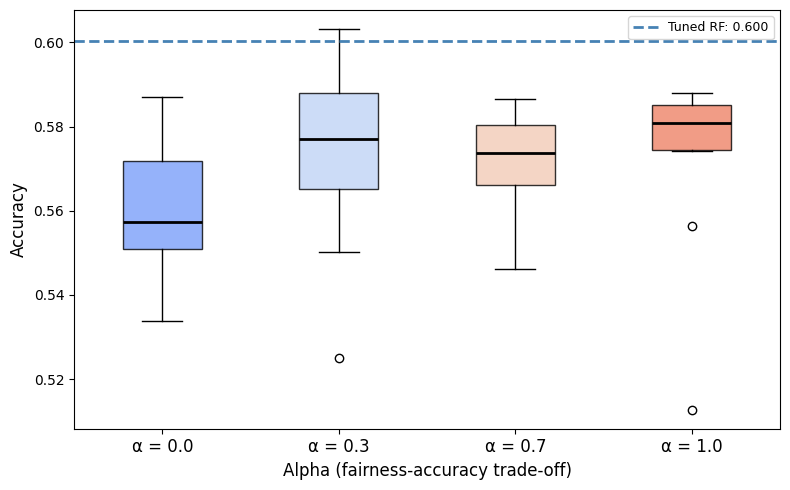

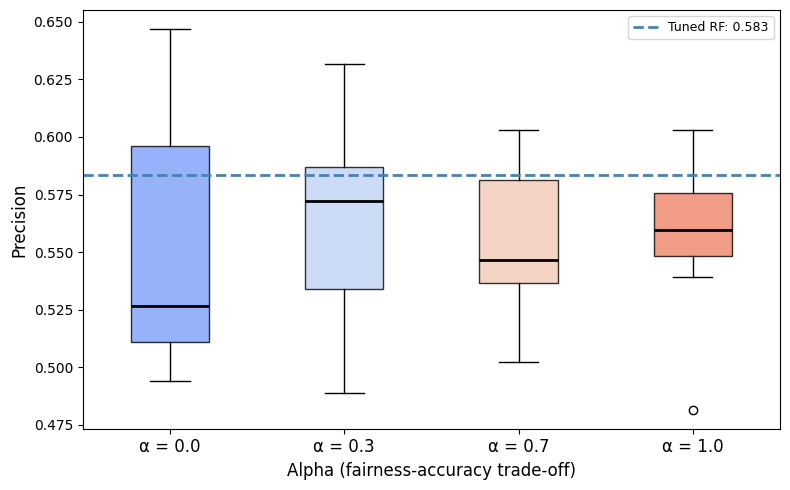

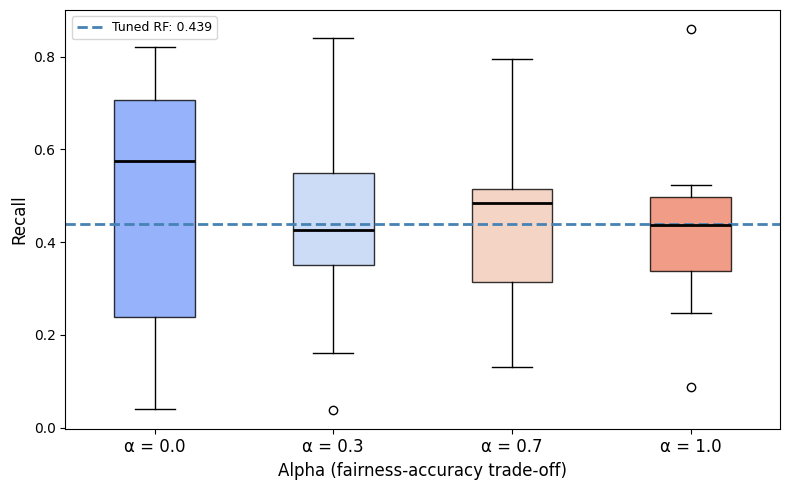

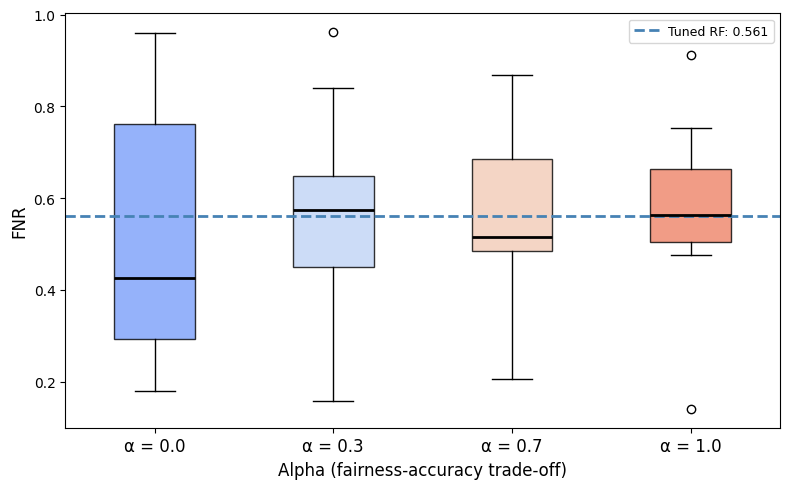

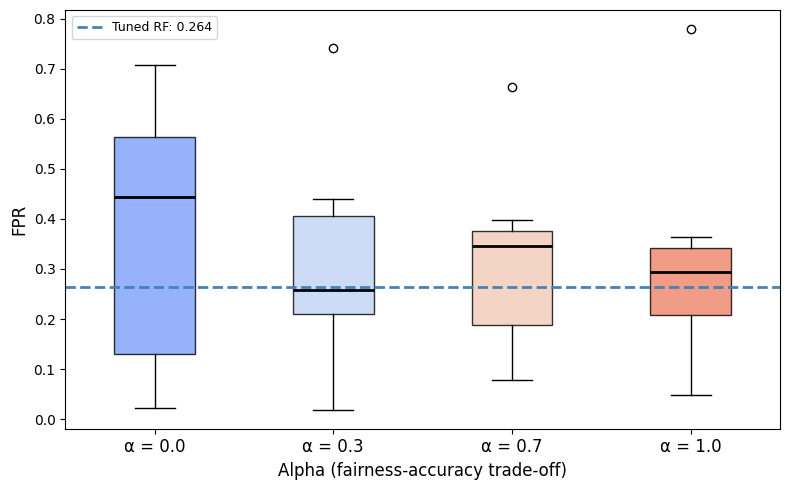

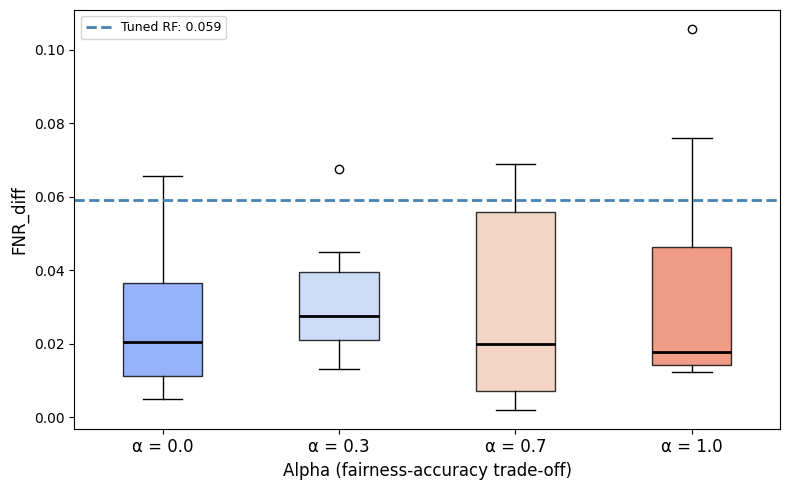

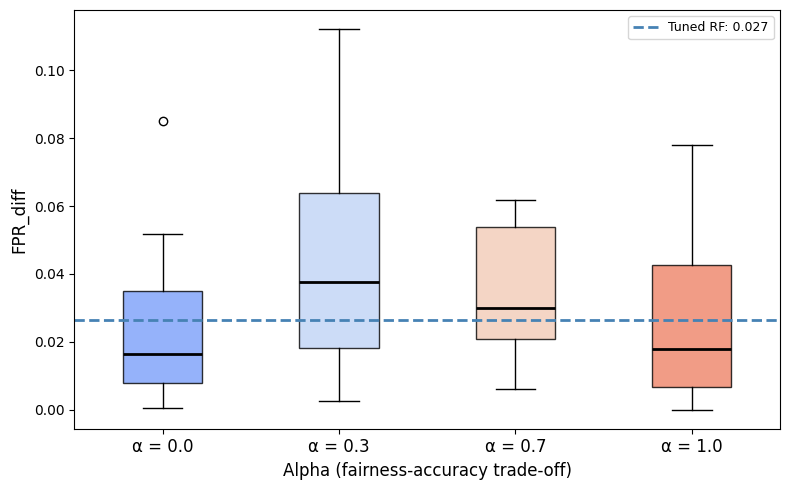

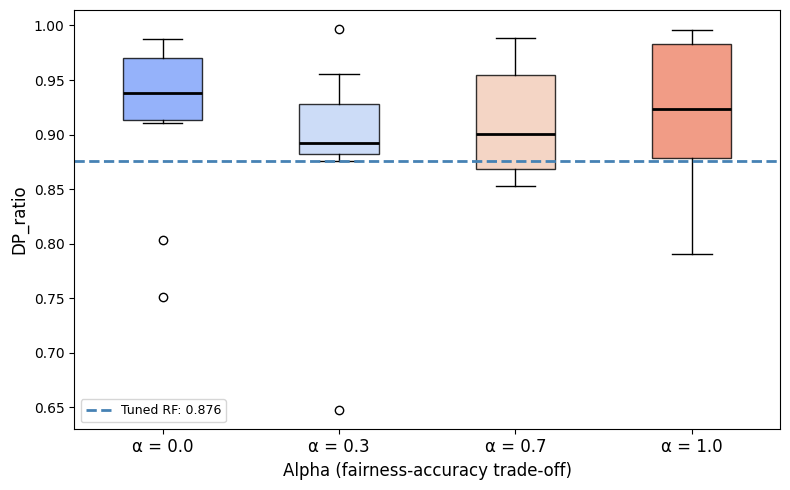

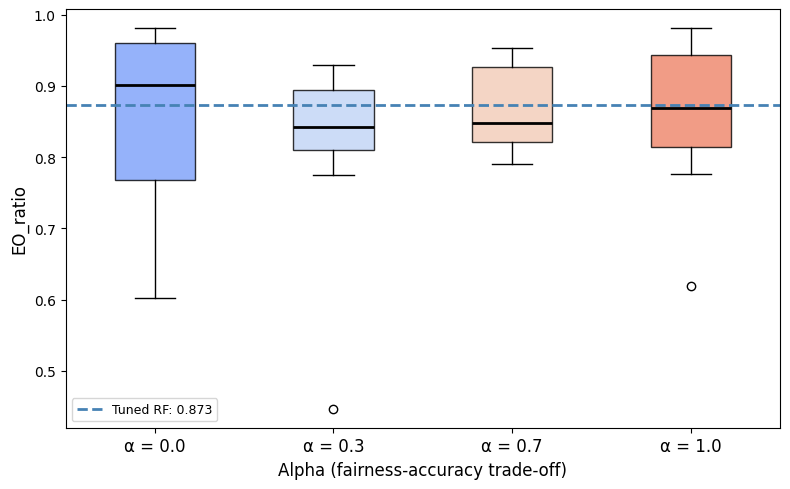

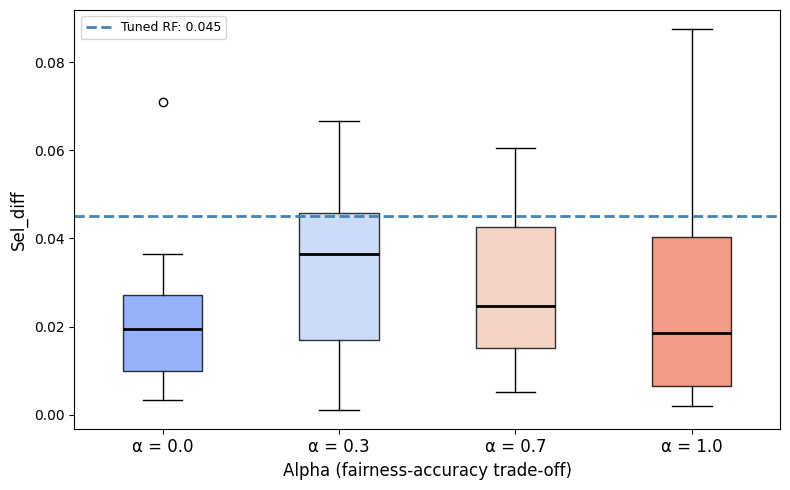

In [ ]:
#@markdown ### Plot all our metrics as line plots while varying alpha
all_metric_keys = list(metric_dict.keys()) + list(FAIRNESS_FUNCS.keys())

# Define metrics_tuned before the loop
metrics_tuned = {
    'overall': metric_frame.overall.to_dict(),
    'FNR_diff': fnr_diff,
    'FPR_diff': fpr_diff,
    'DP_ratio': dp_ratio,
    'EO_ratio': eo_ratio,
    'Sel_diff': sel_diff,
}

for metric in all_metric_keys:
    fig, ax = plt.subplots(figsize=(8, 5))
    data_per_alpha = [afc_results[a][metric] for a in ALPHAS]
    bp = ax.boxplot(data_per_alpha, positions=range(len(ALPHAS)),
                    patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    colors = sns.color_palette("coolwarm", len(ALPHAS))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    # Horizontal reference line: tuned RF
    if metric in metric_dict:
        tuned_val = metrics_tuned['overall'][metric]
    elif metric in FAIRNESS_FUNCS:
        tuned_val = metrics_tuned[metric]
    else:
        raise ValueError(f"Metric '{metric}' not found in tuned results.")

    ax.axhline(tuned_val, color='steelblue', ls='--', lw=2,
               label=f'Tuned RF: {tuned_val:.3f}')

    ax.set_xticks(range(len(ALPHAS)))
    ax.set_xticklabels([f'α = {a}' for a in ALPHAS], fontsize=12)
    ax.set_xlabel('Alpha (fairness-accuracy trade-off)', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    #ax.set_title(f'AFC - {metric} across 10 Seeds and 4 Alpha Values', fontsize=12)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


# Problem 2, Part (d)
### **Threshold Optimizer Post-processing intervention**



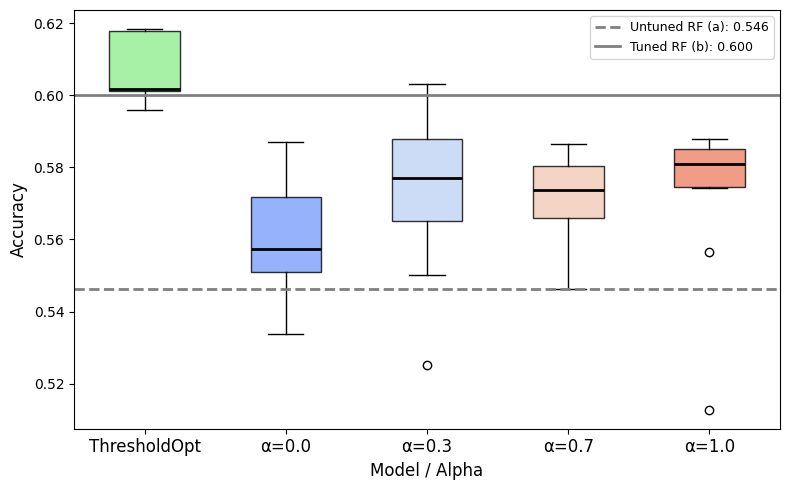

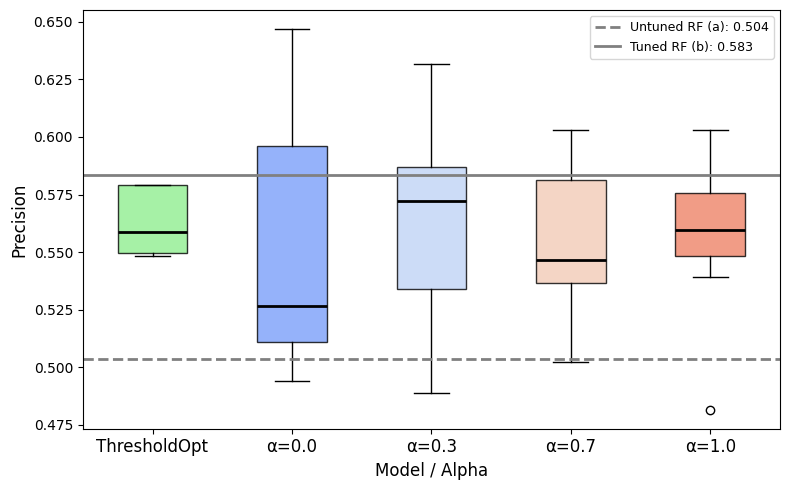

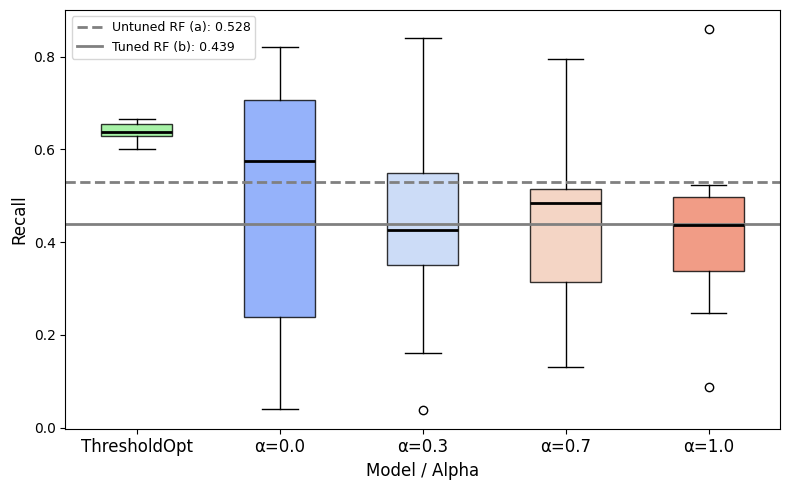

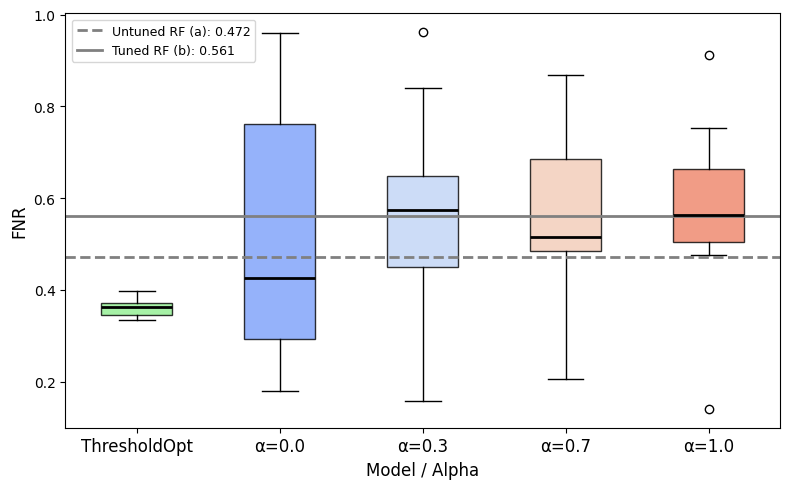

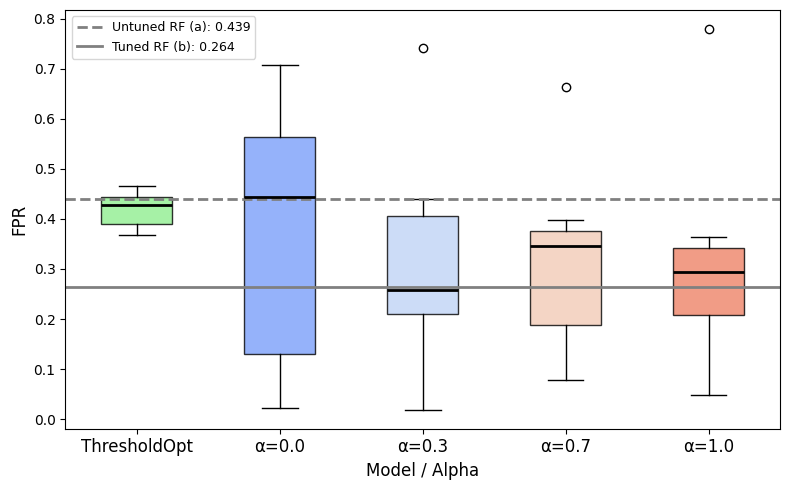

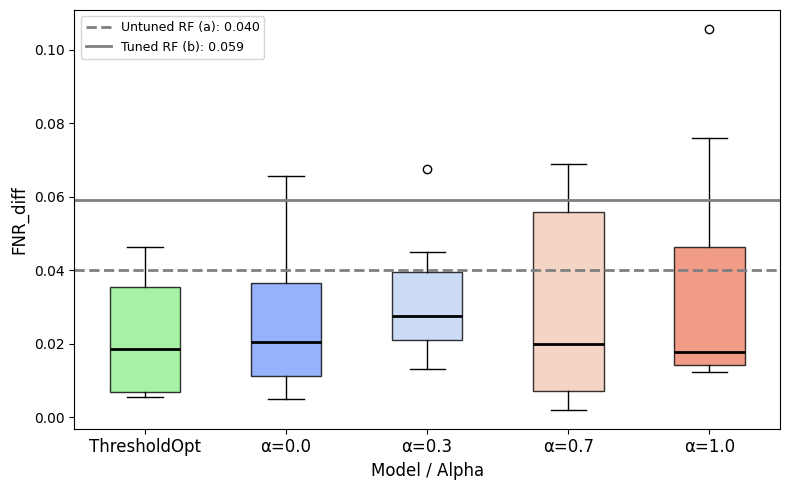

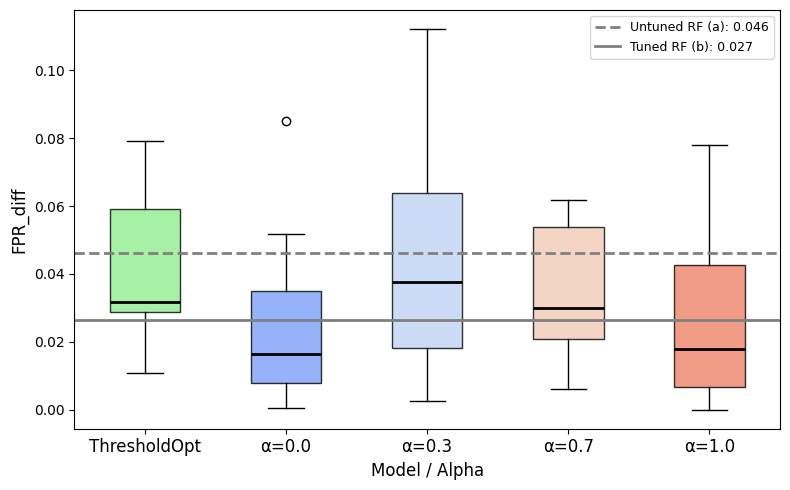

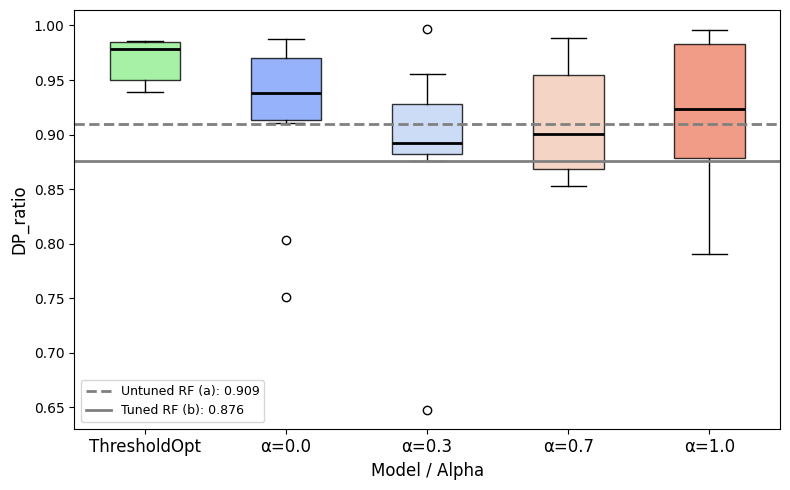

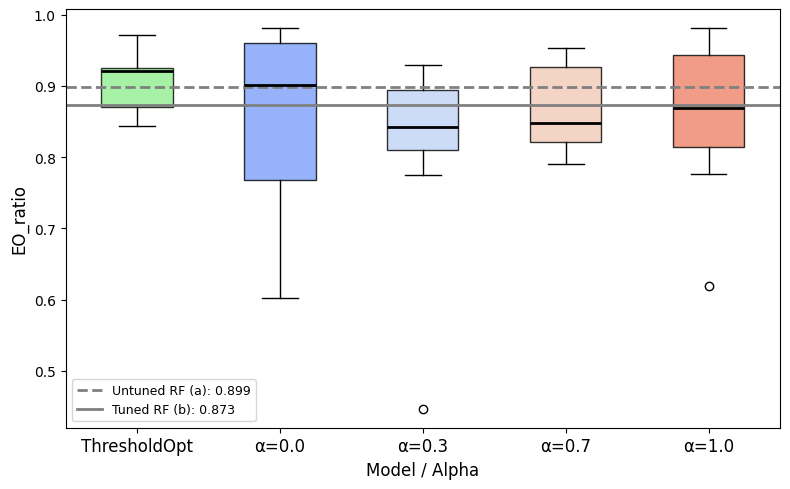

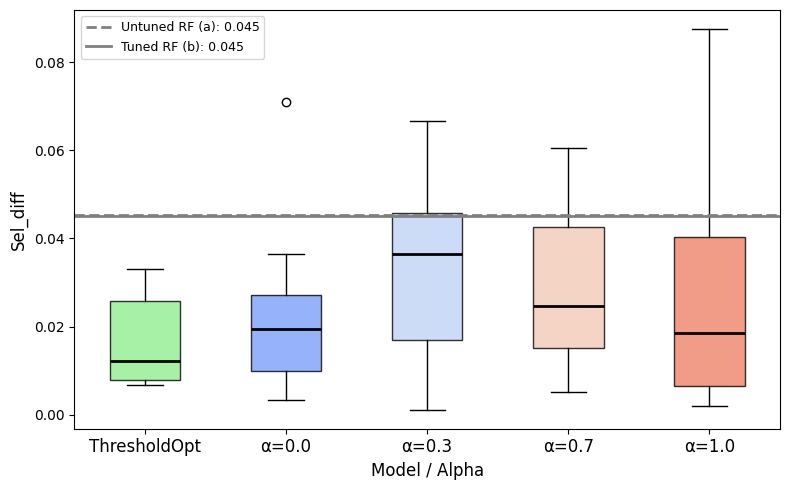

In [ ]:
N_SPLITS = 5
ALPHAS = [0.0, 0.3, 0.7, 1.0]
all_metric_keys = list(metric_dict.keys()) + list(FAIRNESS_FUNCS.keys())

# Containers for results
threshold_results = {k: [] for k in all_metric_keys}
afc_results_for_plot = afc_results

# Run N_SPLITS random train/test splits
for split_seed in range(N_SPLITS):
    # Split data
    X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
        x_numeric, y_raw, test_size=0.2, random_state=split_seed, shuffle=True
    )
    sensitive_train_split = X_train_split['gender_Female']
    sensitive_test_split = X_test_split['gender_Female']

    # Train hyperparameter-tuned RF
    tuned_rf = RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=split_seed)
    tuned_rf.fit(X_train_split, y_train_split)
    y_pred_rf = tuned_rf.predict(X_test_split)

    # Fit ThresholdOptimizer
    # In medical context, minimizing FNR difference is critical (reduce false negatives)
    postproc = ThresholdOptimizer(
        estimator=tuned_rf,
        constraints="equalized_odds",  # balances FPR/FNR across groups
        prefit=True
    )
    postproc.fit(X_train_split, y_train_split, sensitive_features=sensitive_train_split)
    y_pred_post = postproc.predict(X_test_split, sensitive_features=sensitive_test_split)

    # Compute metrics for ThresholdOptimizer
    m_post = compute_all_metrics(y_test_split, y_pred_post, sensitive_test_split)
    for k in metric_dict:
        threshold_results[k].append(m_post['overall'][k])
    for k in FAIRNESS_FUNCS:
        threshold_results[k].append(m_post[k])

# Visualization
for metric in all_metric_keys:
    fig, ax = plt.subplots(figsize=(8,5))

    # Data for plotting
    data_to_plot = [threshold_results[metric]] + [afc_results_for_plot[a][metric] for a in ALPHAS]

    # Boxplot
    positions = range(len(data_to_plot))
    bp = ax.boxplot(
        data_to_plot,
        patch_artist=True,
        medianprops=dict(color='black', lw=2),
        positions=positions
    )
    colors = ['lightgreen'] + sns.color_palette("coolwarm", len(ALPHAS))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    # Horizontal reference lines
    tuned_val = metrics_tuned['overall'][metric] if metric in metric_dict else metrics_tuned[metric]
    untuned_val = metrics_baseline['overall'][metric] if metric in metric_dict else metrics_baseline[metric]

    ax.axhline(untuned_val, color='gray', ls='--', lw=2, label=f'Untuned RF (a): {untuned_val:.3f}')
    ax.axhline(tuned_val, color='gray', ls='-', lw=2, label=f'Tuned RF (b): {tuned_val:.3f}')

    ax.set_xticks(range(len(data_to_plot)))
    ax.set_xticklabels(['ThresholdOpt'] + [f'α={a}' for a in ALPHAS], fontsize=12)
    ax.set_xlabel('Model / Alpha', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()